In [4]:
pip install sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


### Phase 01 -- Fraud landscape

**Business Questions** -- How big is the fraud pronlem and where is it concentrated ?

This notebook establishes the baseline fraud metrics -- overall rates, product breakdowns, card-network and card-type distributions, and amoub=nt distributions. These numbers are the foundation that every subsequent phase builds on.

**Source Data --** 590,540 transacrions, Dec 2017 - Jun 2018, from the IEEE - CIS fraud Detection dataset

**Techniques Showcased --** 'filter' clause, 'Percentile_cont', 'grouping sets'.
 

Each query from sql will be imported as a dataframe and data visualization will be done the get the insights from the query.

In [3]:
# -- 01. Overall fraud_rate by count and by transactional amount

query_1 ="""
select
		count(*) 												as tot_transactions,
		count(*) filter (where is_fraud is true)				as fraud_transactions,
		round(100 * count(*) filter (where is_fraud)
						/count(*),2)							as fraud_rate_count_pct,

		round(sum(transaction_amt),2)							as total_amount,
		round(sum(transaction_amt) filter(where is_fraud),2)	as fraud_amount,
		round(100 * sum(transaction_amt) filter(where is_fraud)
				/ sum(transaction_amt),2)						as fraud_rate_amount_pct
from fraud_dw.fact_transactions;
"""

df1 = pd.read_sql(query_1,engine)
df1

,tot_transactions,fraud_transactions,fraud_rate_count_pct,total_amount,fraud_amount,fraud_rate_amount_pct
0,590540,20663,3.0,79738980.37,3083847.67,3.87


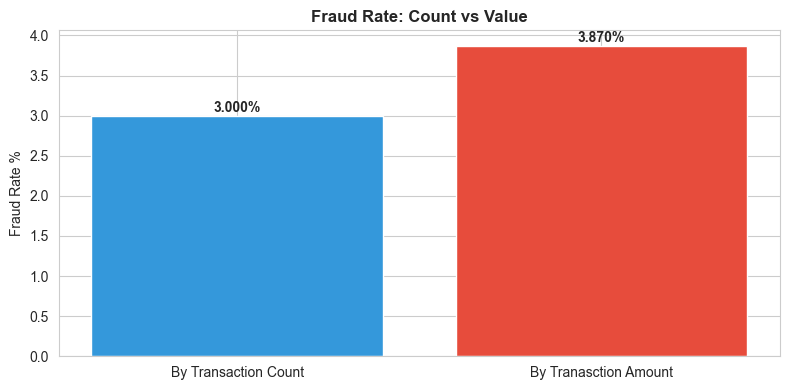

In [5]:
## Query 1 vis

fig, ax = plt.subplots(figsize =(8,4))

categories = ["By Transaction Count", "By Tranasction Amount"]
rates = [df1["fraud_rate_count_pct"].iloc[0],df1["fraud_rate_amount_pct"].iloc[0]]

bars = ax.bar(categories,rates,color = ['#3498db', '#e74c3c'])
ax.set_ylabel("Fraud Rate %")
ax.set_title('Fraud Rate: Count vs Value', fontsize=12, fontweight='bold')

for bar, rate in zip(bars,rates):
    ax.text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.3f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/phase1_q1_fraud_rate_overview.png", bbox_inches='tight')
plt.show()